# DPRL - Assignment 3 Implementation, group 14

**Disclaimer:**
    All of our code is the result of a collaboration between us and ChatGPT in an iterative manner. Although all of the decision making should be attributed to us (it is an LLM after all, sometimes we ended up just coding parts by ourselves), it proved to be a valuable tool in speeding up the documentation, styling and creative process, helping to push the overall quality of our final notebook upon request.

In [1]:
import math
import random
import copy
import numpy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Encoding of the initial board
- Manually encoded initial board state based on the provided image
- We use 1 for our (MCTS) pieces, 2 for the opponent's, 0 otherwise (empty)
- The board is encoded from left to right and from bottom to top

In [3]:
initial_state = [
    [2, 1, 1, 1, 2, 2, 1],  # Bottom row (Row 1)
    [0, 1, 2, 2, 1, 2, 0],  # Row 2
    [0, 1, 1, 1, 2, 1, 0],  # Row 3
    [0, 2, 2, 2, 1, 2, 0],  # Row 4
    [0, 1, 1, 2, 2, 1, 0],  # Row 5
    [0, 1, 2, 2, 1, 2, 0],  # Top row (Row 6)
] #  1  2  3  4  5  6  7  <- Columns

### Connect4 implementation
- The *__init__* method initializes the game with a given state and sets the MCTS agent to play first.
- The *get_possible_actions* method computes the list of columns where a new piece can be legally placed (i.e., not full).
- The *is_terminal* method checks if the game has reached an end state, identifying wins for either player or a draw.
- The *check_winner* method inspects the board for a four-in-a-row condition horizontally, vertically, or diagonally for either player (used by *is_terminal*.
- The *play* method executes a move by placing a piece in the chosen column (only if it's a legal move!) and toggles the player turn, also checking for terminal state after the move.

In [4]:
class Connect4:
    def __init__(self, state):
        self.rows = 6
        self.columns = 7
        self.state = np.array(state)
        self.player_turn = 1  # Set the MCTS as the first player
        
    def __str__(self):
        board_str = ""
        for row in reversed(self.state):  # Reverse the board to start from the top for printing
            board_str += ' '.join(str(cell) for cell in row) + "\n"
        return board_str
    
    def get_possible_actions(self):
        # Actions are possible in columns that are not full (top cell is empty)
        return [c for c in range(self.columns) if self.state[5][c] == 0]

    def is_terminal(self):
        # Check for win in rows, columns, and diagonals for both players
        for player in [1, 2]:
            if self.check_winner(player):
                return True, 1 if player == 1 else -1
        
        # Check for draw (if no empty cells left)
        if not np.any(self.state == 0):
            return True, 0  # Draw
        
        return False, None  # Not a terminal state

    def check_winner(self, player):
        # Check horizontal, vertical, and diagonal (\ and /) for a win
        for row in range(self.rows):
            for col in range(self.columns - 3):
                if all(self.state[row, col:col + 4] == player):
                    return True  # Horizontal win
        for col in range(self.columns):
            for row in range(self.rows - 3):
                if all(self.state[row:row + 4, col] == player):
                    return True  # Vertical win
        for col in range(self.columns - 3):
            for row in range(self.rows - 3):
                if all(self.state[row + i][col + i] == player for i in range(4)):
                    return True  # Diagonal (\) win
                if all(self.state[row + 3 - i][col + i] == player for i in range(4)):
                    return True  # Diagonal (/) win
        return False

    def play(self, action):
        # Check if the column is full
        if self.state[5][action] != 0:
            raise ValueError(f"Column {action + 1} is full. Please choose another column.")

        # Play a piece in the chosen column
        for row in range(self.rows):
            if self.state[row][action] == 0:
                self.state[row][action] = self.player_turn
                break
        
        # Check if this move ends the game
        terminal, reward = self.is_terminal()
        
        # Switch player
        self.player_turn = 3 - self.player_turn
        return terminal, reward

    def get_next_state(self, action):
        # Make sure this method creates a deep copy of the game,
        # plays the move, and returns the new game state
        new_game = copy.deepcopy(self)
        terminal, _ = new_game.play(action)
        return new_game

### Visualizer for the games
 - The *render* method visualizes the game board using matplotlib, indicating the current player or the winner.
- It includes a *find_winning_tiles* method that identifies the four connecting tiles that led to a win, highlighting them in yellow.
- The colors are chosen to be dark blue for the MCTS agent, light blue for the Random agent, with a clear distinction for winning sequences.
- The title dynamically updates to reflect the current state of the game or the outcome if the game has ended.
- A legend is included to identify the MCTS agent and the Random agent with their respective colors.

In [5]:
class Connect4Visualizer(Connect4):
    def __init__(self, state, player_turn=1):
        super().__init__(state)
        self.player_turn = player_turn
        
    def find_winning_tiles(self):
        # Check for four consecutive tiles horizontally, vertically, and diagonally
        for player in [1, 2]:
            for row in range(self.rows):
                for col in range(self.columns - 3):
                    if all(self.state[row, col:col + 4] == player):
                        return [(row, col + i) for i in range(4)]
            for col in range(self.columns):
                for row in range(self.rows - 3):
                    if all(self.state[row:row + 4, col] == player):
                        return [(row + i, col) for i in range(4)]
            for col in range(self.columns - 3):
                for row in range(self.rows - 3):
                    if all(self.state[row + i][col + i] == player for i in range(4)):
                        return [(row + i, col + i) for i in range(4)]
                    if all(self.state[row + 3 - i][col + i] == player for i in range(4)):
                        return [(row + 3 - i, col + i) for i in range(4)]
        return []

    def render(self):
        terminal, reward = self.is_terminal()
        winning_tiles = self.find_winning_tiles() if terminal else []

        # Define colors: white for empty, dark blue for MCTS agent's pieces, light blue for Random agent's pieces
        # We're not adding yellow here because it's only for temporary highlighting
        cmap = ListedColormap(['white', 'darkblue', 'lightblue'])
        fig, ax = plt.subplots()

        # Create a copy of the state to modify for display
        display_state = np.copy(self.state)

        # If we have winning tiles, change their value to a number that's not 1 or 2 to not confuse with player colors
        if winning_tiles:
            for row, col in winning_tiles:
                display_state[row, col] = 3  # Temporary value for winning tiles

        # We flip the y-axis to have the [0][0] at the bottom left corner
        # and add 1 to the row and column indices for 1-based numbering
        ax.matshow(np.flipud(display_state), cmap=cmap)

        # Highlight winning tiles by changing the color to yellow
        if winning_tiles:
            for row, col in winning_tiles:
                # Flip the row index for display because we've flipped the display array
                ax.add_patch(plt.Rectangle((col - 0.5, 4.5 - row), 1, 1, color='yellow'))

        # Draw gridlines
        for (i, j), val in np.ndenumerate(np.flipud(display_state)):
            ax.text(j, i, '', ha='center', va='center')

        # Set ticks and labels with 1-based numbering
        ax.set_xticks(np.arange(-0.5, 7, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
        plt.xticks(range(7), [str(i+1) for i in range(7)])
        plt.yticks(range(6), [str(6-i) for i in range(6)])

        # Hide major tick labels
        ax.tick_params(which='major', top=False, bottom=False, left=False, right=False, labelbottom=True)

        # Set axis labels
        plt.xlabel('Columns')
        plt.ylabel('Rows')

        # Modify title to show the winning agent or the current player
        if terminal:
            winner = "MCTS agent" if reward == 1 else "Random agent"
            plt.title(f"{winner} won!", fontsize=16)
        else:
            player = "MCTS agent" if self.player_turn == 1 else "Random agent"
            plt.title(f"Current state of the game. {player} to play", fontsize=16)

        # Create a legend for the colors without white and yellow
        colors = [plt.plot([],[], color=cmap.colors[i], ls="", marker="s", markersize=np.sqrt(100))[0] for i in [1, 2]]
        labels = ['MCTS agent', 'Random agent']
        plt.legend(colors, labels, numpoints=1, markerscale=1, loc='upper right', bbox_to_anchor=(1.15, 1))

        # Display the game state
        plt.show()

#### First visualization

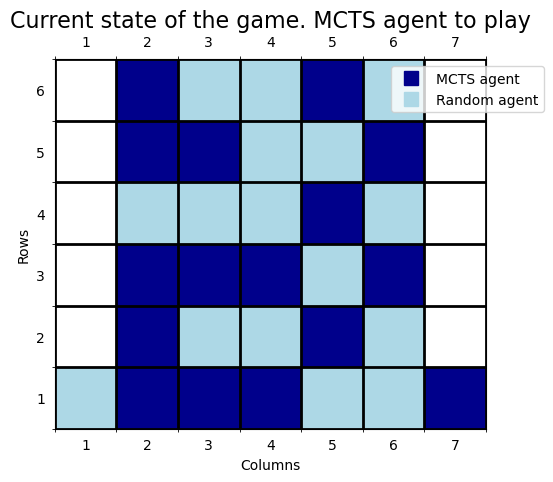

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Now let's use this new visualizer class to display the game state with the updated requirements
visual_game = Connect4Visualizer(initial_state)
visual_game.render()  # To check the initial board state

#### Some additional testing (the next 4 cells can be ignored)

Possible actions (columns where a piece can be played): [0, 6]

Remember that 1 is MCTS agent, 2 random, 0 empty
Piece in (row,col) = (4,5): 1
Piece in (row,col) = (5,5): 2
Piece in (row,col) = (5,6): 1
Piece in (row,col) = (5,7): 0

Playing in column 1


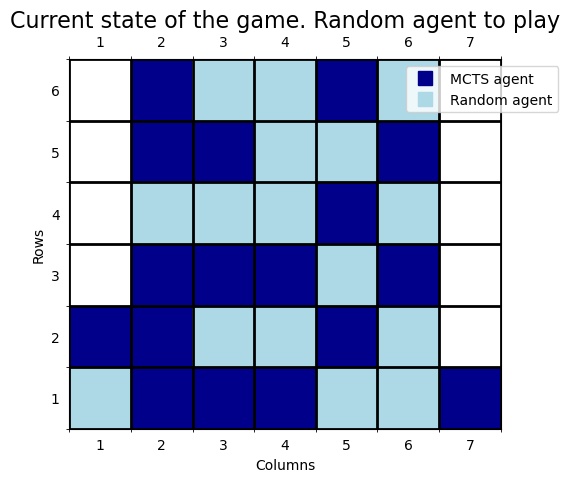

Terminal state reached: False
Reward: None


In [7]:
import numpy as np

game = Connect4(initial_state)
possible_actions = game.get_possible_actions()
print("Possible actions (columns where a piece can be played):", possible_actions)


# Checking that the coordinates work as intended
print("\nRemember that 1 is MCTS agent, 2 random, 0 empty\nPiece in (row,col) = (4,5):",game.state[3,4])
print("Piece in (row,col) = (5,5):",game.state[4,4])
print("Piece in (row,col) = (5,6):",game.state[4,5])
print("Piece in (row,col) = (5,7):",game.state[5,6])
print("")

# Now, let's play a piece in one of the possible actions
# For this example, we'll just take the first possible action
action_to_play = possible_actions[0]
print(f"Playing in column {action_to_play + 1}")  # Adding 1 for 1-based indexing

# Play the action and check if the game reaches a terminal state and the reward
terminal, reward = game.play(action_to_play)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

# Print the result of the play
print("Terminal state reached:", terminal)
print("Reward:", reward)

#### Preventing illegal moves from happening (testing 2/4)

In [8]:
# Illegal move check
game.play(1)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

ValueError: Column 2 is full. Please choose another column.

#### Checking the visualization updates as expected (testing 3/4)

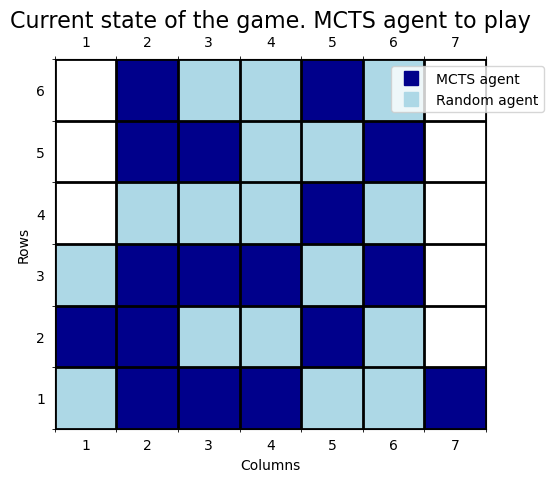

In [9]:
# Light player plays 1st column
game.play(0)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

#### Reaching terminal state (testing 4/4)

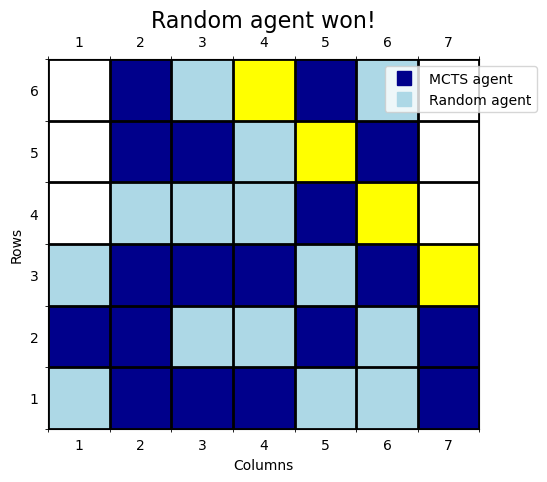

In [10]:
# Dark player plays last column and then light players wins by either playing first or last column
game.play(6)
game.play(6)

# Render the new state of the game
visual_game_after_play = Connect4Visualizer(game.state,game.player_turn)
visual_game_after_play.render()

In [12]:
import math

class Node:
    def __init__(self, game, parent=None, move=None):
        self.game = game
        self.parent = parent
        self.move = move
        self.children = []
        self.wins = 0
        self.visits = 1
        self.untried_moves = game.get_possible_actions()
        self.player_turn = game.player_turn
        
    def uct_select_child(self):
        # Selection of the child with the highest UCT score
        """From here only for testing"""


        for child in self.children:
            uct_value = child.wins / child.visits + math.sqrt(2 * math.log(self.visits) / child.visits)
            print(f"Child move {child.move}: UCT Value = {uct_value}")
        """Until here"""
        return max(self.children, key=lambda child: (child.wins / child.visits) + math.sqrt(2 * math.log(self.visits) / child.visits))

    def expand(self):
        # Expands the node by creating a new child node for an untried move
        while self.untried_moves:
            move  = self.untried_moves.pop(0) # Select and remove the move from the list of untried moves
        
            print(f"Expanding move: {move + 1}")
            new_game_state = self.game.get_next_state(move)
            child_node = Node(new_game_state, parent=self, move=move)
            self.children.append(child_node)
        return child_node

    def simulate(self):
        simulation_game = copy.deepcopy(self.game)
        i = 0
        while not simulation_game.is_terminal()[0]:
            possible_moves = simulation_game.get_possible_actions()
            if i==0:
                print(f"Simulating a game from state:\n{self.game}")
            move = random.choice(possible_moves)
            print(f"Playing move: {move + 1}")
            simulation_game.play(move)
            print(f"New state after move:\n{simulation_game}")
            i+=1
        return simulation_game.is_terminal()[1]

    def backpropagate(self, result):
        print(f"Backpropagating result: {result} for move: {self.move+1 if self.move is not None else None}")
        if result == 1:
            self.wins += result
       
        print("result is: " ,result)
        self.visits += 1
        
        if self.parent:
            self.parent.backpropagate(result)
    

In [13]:
def monte_carlo_tree_search(root_game, iterations):
    root_node = Node(root_game)

    for _ in range(iterations):
        node = root_node
        # Selection
        print(node.move, node.children)
        
        if node.children:  # We use 'and' to make sure it has children to select from
            node = node.uct_select_child()
        # Expansion
        print(node, node.untried_moves)
        if node.untried_moves:  # Check if there are moves to try
            node = node.expand()  # Do not pass 'move' here
        
        # Simulation
        result = node.simulate()
        # Backpropagation
        node.backpropagate(result)
    
    

    print("Action statistics at the root node:")
    for child in root_node.children:
        print(f"Action {child.move + 1}: Wins = {child.wins}, Visits = {child.visits}, Win Rate = {child.wins / child.visits if child.visits > 0 else 'N/A'}")
    # Select the action with the highest win percentage
    return max(root_node.children, key=lambda c: c.wins / c.visits).move

In [14]:
# Usage example:
root_game = Connect4(initial_state)
best_move = monte_carlo_tree_search(root_game, 1000)
print(f"The best move is to play in column {best_move + 1}")

None []
<__main__.Node object at 0x000001C0D1DAB910> [0, 6]
Expanding move: 1
Expanding move: 7
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 2
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 1.1774100225154747
Child move 6: UCT Value = 0.8325546111576977
<__main__.Node object at 0x000001C0D1D87850> [0, 6]
Expanding move: 1
Expanding move: 7
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
1 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.8030286688676521
Child move 6: UCT Value = 0.8160156818546651
<__main__.Node object at 0x000001C0D1DD3190> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
1 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
1 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 1
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.7590297507258612
Child move 6: UCT Value = 0.724481962482098
<__main__.Node object at 0x000001C0D1D87850> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
2

Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 2
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.6958147130299123
Child move 6: UCT Value = 0.6976317176258018
<__main__.Node object at 0x000001C0D1DD3190> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 2
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 1
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 1
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.6800987986980787
Child move 6: UCT Value = 0.6709001426239729
<__main__.Node object at 0x000001C0D1D87850> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0


New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 1
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0D1D8785

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 2
0 1 1 2 2 1 1
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 2
0 1 1 2 2 1 1
0 2 2 2 1 2 2
1 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.6390358324348406
Child move 6: UCT Value = 0.6418460237873468
<__main__.Node object at 0x000001C0D1DD3190> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0


Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D1D87850>, <__main__.Node object at 0x000001C0D1DD3190>]
Child move 0: UCT Value = 0.6271709834143401
Child move 6: UCT Value = 0.6271773852187457
<__main__.Node object at 0x000001C0D1DD3190> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 

In [15]:
def play_full_game(root_state):
    current_state = root_state
    while not current_state.is_terminal()[0]:
        # MCTS agent turn
        best_move = monte_carlo_tree_search(current_state, 10)
        current_state.play(best_move)
        
        if current_state.is_terminal()[0]:
            break
        
        # Random agent turn
        random_move = random.choice(current_state.get_possible_actions())
        current_state.play(random_move)
    
    return current_state.is_terminal()[1]  # Return the game result

# To simulate many games and estimate win average
def simulate_games(num_games):
    mcts_wins = 0
    for _ in range(num_games):
        initial_game_state = Connect4(initial_state)
        result = play_full_game(initial_game_state)
        if result == 1:  # Assuming 1 represents a win for the MCTS agent
            mcts_wins += 1
    return mcts_wins / num_games

# Example usage:
win_rate = simulate_games(100)
print(f"MCTS agent win rate: {win_rate}")

None []
<__main__.Node object at 0x000001C0D1DB4BD0> [0, 6]
Expanding move: 1
Expanding move: 7
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
1 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D1DE6650>, <__main__.Node object at 0x000001C0D1DFC350>]
Child move 0: UCT Value = 1.1774100225154747
Child move 6: UCT Value = 1.3325546111576978
<__main__.Node object at 0x000001C0D1DFC350> [0, 6]
Expanding move: 1
Expanding move: 7
Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 1
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0D208B210>, <__main__.Node object at 0x000001C0D20B0E50>]
Child move 0: UCT Value = 0.9465092364124227
Child move 6: UCT Value = 1.0929347248663588
<__main__.Node object at 0x000001C0D20B0E50> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
2 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: -1 for move: 7
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D208B210>, <__main__.

Playing move: 7
New state after move:
1 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 7
result is:  0
Backpropagating result: 0 for move: None
result is:  0
Action statistics at the root node:
Action 7: Wins = 0, Visits = 11, Win Rate = 0.0
None []
<__main__.Node object at 0x000001C0CF8C2450> [6]
Expanding move: 7
Simulating a game from state:
1 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 7
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0D1D31C10>]
Child move 6: UCT Value = 0.8325546111576977
<__main__.Node object at 0x000001C0D1D31C10> [6]
Expanding move: 7
Backpropagating result: 0 for move: 7
result is:  0
Backpropagating result: 0 for move: 7
result is:  

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 2
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 2
1 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
2 1 2 2 1 2 2
1 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 1
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0D208039

New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 2
0 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 2
1 1 1 1 2 1 1
2 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D20D4E10>, <__main__.Node object at 0x000001C0D20D4FD0>]
Child move 0: UCT Value = 1.1120178817720265
Child move 6: UCT Value = 1.269666990168809
<__main__.Node object at 0x000001C0D20D4FD0> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
0 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0

...

Backpropagating result: -1 for move: 1
result is:  -1
Backpropagating result: -1 for move: None
result is:  -1
None [<__main__.Node object at 0x000001C0D20B2950>, <__main__.Node object at 0x000001C0D20B1E50>]
Child move 0: UCT Value = 0.8760869616261554
Child move 6: UCT Value = 0.9597051824376163
<__main__.Node object at 0x000001C0D20B1E50> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 2
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 2
1 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
2 1 2 2 1 2 2
1 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 7
result is:  0
Backpropagating result: 0 for move: None
result is:  0
Action statistics at the root node:
Action 1: Wins = 0, Visits

Child move 0: UCT Value = 1.3325546111576978
Child move 6: UCT Value = 1.1774100225154747
<__main__.Node object at 0x000001C0D2089790> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
1 1 1 1 2 1 0
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 1
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D2089790>, <__main__.Node object at 0x000001C0D208BA10>]
Child move 0: UCT Value = 1.3637532843256834
Child move 6: UCT Value = 1.2102959906117234
<__main__.Node object at 0x000001C0D2089790> []
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 0
0 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2

None []
<__main__.Node object at 0x000001C0D1C7E290> [6]
Expanding move: 7
Simulating a game from state:
1 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 7
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0CF896F50>]
Child move 6: UCT Value = 0.8325546111576977
<__main__.Node object at 0x000001C0CF896F50> [6]
Expanding move: 7
Simulating a game from state:
1 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
1 1 2 2 1 2 0
2 1

New state after move:
0 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 0
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 1
New state after move:
2 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 0
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
2 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 0
2 1 1 1 2 1 1
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
2 1 2 2 1 2 0
2 1 1 2 2 1 0
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
2 1 2 2 1 2 0
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Playing move: 7
New state after move:
2 1 2 2 1 2 2
2 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 1
2 1 1 1 2 2 1

Backpropagating result: 0 for move: 1
result is:  0
Backpropagating result: 0 for move: None
result is:  0
None [<__main__.Node object at 0x000001C0D20A2FD

New state after move:
0 1 2 2 1 2 1
0 1 1 2 2 1 1
0 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Backpropagating result: 1 for move: 7
result is:  1
Backpropagating result: 1 for move: None
result is:  1
None [<__main__.Node object at 0x000001C0D20A8D10>, <__main__.Node object at 0x000001C0D20AB850>]
Child move 0: UCT Value = 1.1774100225154747
Child move 6: UCT Value = 1.3325546111576978
<__main__.Node object at 0x000001C0D20AB850> [0, 6]
Expanding move: 1
Expanding move: 7
Simulating a game from state:
0 1 2 2 1 2 0
0 1 1 2 2 1 0
0 2 2 2 1 2 2
0 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
0 2 2 2 1 2 2
0 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
0 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 1
New state after move:
0 1 2 2 1 2 0
0 1 1 2 2 1 1
1 2 2 2 1 2 2
2 1 1 1 2 1 1
1 1 2 2 1 2 2
2 1 1 1 2 2 1

Playing move: 7
New state 